In [ ]:
# 1. Scan and add the host key
!mkdir -p ~/.ssh && ssh-keyscan -H 191.101.113.5 >> ~/.ssh/known_hosts

# 2. Run your original rsync command again
!rsync -avz --exclude='Results/' /content/drive/MyDrive/Thp/ ali@191.101.113.5:~/Documents/ensemble/code

SyntaxError: invalid syntax (1772535766.py, line 1)

Permission denied, please try again.
Permission denied, please try again.
ali@191.101.113.5: Permission denied (publickey,password).
rsync: connection unexpectedly closed (0 bytes received so far) [sender]
rsync error: unexplained error (code 255) at io.c(232) [sender=3.2.7]


In [ ]:
!rsync -avz --exclude='Results/' /content/drive/MyDrive/Thp/ ali@191.101.113.5:~Documents/ensemble/code

Host key verification failed.
rsync: connection unexpectedly closed (0 bytes received so far) [sender]
rsync error: unexplained error (code 255) at io.c(232) [sender=3.2.7]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.chdir('/content/drive/MyDrive/Thp')
# Set the PYTHONPATH environment variable to include the directory containing your modules
os.environ['PYTHONPATH'] = '/content/drive/MyDrive/Thp'

from Funcs.Functions import *
from Funcs.Model_functions import *
import Funcs
from Lib.lib import *

In [ ]:
!pip install scikit-learn==1.3.2
!pip install --upgrade pandas

In [ ]:
# %run codes/evaluation.py

modified code version_


KeyboardInterrupt: 

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Thp/Data/UCI_HAR_Dataset/data_uci_handled.csv')

In [ ]:
data.head()

,Unnamed: 0,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity,ActivityName,subject
0,0,0.277148,-0.017614,-0.107404,-0.995962,-0.987683,-0.991548,-0.996531,-0.988120,-0.989661,...,0.066452,0.283066,0.687887,-0.327143,0.487364,-0.563003,-0.433471,5,LAYING,2
1,1,0.367480,0.006833,-0.121350,-0.352558,0.027237,-0.180255,-0.394882,0.066738,-0.185829,...,-0.400080,0.612670,-0.912706,0.807202,-0.567420,0.343841,0.187630,0,WALKING,21
2,2,0.300059,-0.015394,-0.107383,-0.960979,-0.988279,-0.982935,-0.960257,-0.987573,-0.981137,...,0.059721,-0.573286,0.044519,-0.031686,0.864964,-0.433596,-0.524928,5,LAYING,19
3,3,0.265428,-0.007881,-0.089914,-0.991753,-0.977334,-0.969756,-0.992989,-0.975300,-0.969643,...,0.008593,0.123959,0.029775,-0.282624,-0.671481,-0.098258,-0.104123,3,SITTING,24
4,4,0.326544,-0.021950,-0.097946,-0.369203,-0.232375,0.300656,-0.355518,-0.262997,0.282425,...,-0.584803,-0.476609,0.379183,0.617257,-0.656394,0.176642,0.250977,0,WALKING,7


In [ ]:
# %run codes/evaluation.py

In [ ]:
res1 = pd.read_pickle('Results/finall_res2.pkl')
res2 = pd.read_pickle('Results/finall_res1.pkl')
res = pd.concat([res1, res2])

In [ ]:
base_learners = get_models()
base_learners.pop('gn')
base_learners.pop('sgd')

SGDClassifier(loss='log', n_jobs=-1)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define your ensemble use dictionary
use_ensemble = {'diste': True, 'avge': True, 'acce': False, 'maxe': True, 'densitye': True}

# Initialize a list to store all results
results_list = []

# modified_base_learners = base_learners.pop('sgd')
for index, row in res.iterrows():
    final_res = row['best_res_nested']['final_res']
    scores = [final_res[i]['cr_single']['single_svm']['weighted avg']['f1-score'] for i in range(len(final_res))]
    mean_scores = np.mean(scores)
    std_scores = np.std(scores)
    max_scores = np.max(scores)
    min_scores = np.min(scores)

    print(f'SVM Results (n_c: {row.n_c}, phi: {row.phi}):')
    print('Mean F1-Score:', mean_scores)
    print('STD F1-Score:', std_scores)
    print('Max F1-Score:', max_scores)
    print('Min F1-Score:', min_scores)

    ensemble_res_dict = dict()
    for base_learner in base_learners:
        print(f'-------------------- Results for {base_learner} model (n_c: {row.n_c}, phi: {row.phi}) -------------------- \n')
        for sub_model in use_ensemble.keys():
            if use_ensemble[sub_model]:
                ensemble_scores = [final_res[i]['cr'][base_learner][sub_model]['weighted avg']['f1-score'] for i in range(len(final_res))]
                st_indexes = {'mean': np.mean(ensemble_scores), 'std': np.std(ensemble_scores), 'max': np.max(ensemble_scores),
                              'min': np.min(ensemble_scores)}
                ensemble_res_dict[sub_model] = {'scores': ensemble_scores, 'st_indexes': st_indexes}
                print(f'{base_learner}_{sub_model}_mean_scores', st_indexes['mean'])
                print(f'{base_learner}_{sub_model}_std_scores', st_indexes['std'])
                print(f'{base_learner}_{sub_model}_max_scores', st_indexes['max'])
                print(f'{base_learner}_{sub_model}_min_scores', st_indexes['min'])

                # Append results to the list
                results_list.append({
                    'base_learner': base_learner,
                    'ensemble_method': sub_model,
                    'n_c': row.n_c,
                    'phi': row.phi,
                    'mean_score': st_indexes['mean'],
                    'std_score': st_indexes['std'],
                    'max_score': st_indexes['max'],
                    'min_score': st_indexes['min'],
                    'scores': ensemble_scores
                })

SVM Results (n_c: 2, phi: 0.1):
Mean F1-Score: 0.9205415473492626
STD F1-Score: 0.02299059537038439
Max F1-Score: 0.9493801983708969
Min F1-Score: 0.8729021248023463
-------------------- Results for svm model (n_c: 2, phi: 0.1) -------------------- 

svm_diste_mean_scores 0.8321274140298337
svm_diste_std_scores 0.09493428807327042
svm_diste_max_scores 0.9072288567166619
svm_diste_min_scores 0.6602969115081717
svm_avge_mean_scores 0.4420261134664508
svm_avge_std_scores 0.10270946066229654
svm_avge_max_scores 0.5525595154901259
svm_avge_min_scores 0.18878509680890967
svm_maxe_mean_scores 0.44228256781910424
svm_maxe_std_scores 0.10211350728772273
svm_maxe_max_scores 0.5525595154901259
svm_maxe_min_scores 0.19183360612101316
svm_densitye_mean_scores 0.7978298831180097
svm_densitye_std_scores 0.09085394821756138
svm_densitye_max_scores 0.8635198804626077
svm_densitye_min_scores 0.6339709342463624
-------------------- Results for lr model (n_c: 2, phi: 0.1) -------------------- 

lr_diste_m

In [ ]:
# Convert results list to DataFrame
df_results = pd.DataFrame(results_list)

# Sort by mean_score to find the best model
df_results_sorted = df_results.sort_values(by='mean_score', ascending=False)

# Display the top models
print("Top Ensemble Models by Mean F1-Score:")
print(df_results_sorted.head())

Top Ensemble Models by Mean F1-Score:
    base_learner ensemble_method  n_c  phi  mean_score  std_score  max_score  \
647           lr        densitye    6  0.5    0.973269   0.002896   0.977670   
503           lr        densitye    5  0.5    0.973084   0.002255   0.978155   
215           lr        densitye    3  0.5    0.972907   0.002564   0.978183   
359           lr        densitye    4  0.5    0.972814   0.002516   0.978168   
663           lr        densitye    6  0.6    0.972645   0.002092   0.978159   

     min_score                                             scores  
647   0.967414  [0.9703582294526875, 0.97228441650441, 0.97474...  
503   0.969408  [0.9694078692167947, 0.9718427175077576, 0.975...  
215   0.968874  [0.9703613327982019, 0.9727783464736125, 0.975...  
359   0.968388  [0.971829136480411, 0.9732948858848892, 0.9742...  
663   0.969368  [0.9728072251571386, 0.9752148653860312, 0.971...  


In [ ]:
single_res = [final_res[i]['cr_single']['single_svm']['weighted avg']['f1-score'] for i in range(len(final_res))]

In [ ]:
combined_df

,base_learner,ensemble_method,n_c,phi,mean_score,std_score,max_score,min_score,scores
647,lr,densitye,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.970358
647,lr,densitye,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.972284
647,lr,densitye,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.974744
647,lr,densitye,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.973340
647,lr,densitye,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.967454
...,...,...,...,...,...,...,...,...,...
15,single_svm,single_svm,NaN,NaN,NaN,NaN,NaN,NaN,0.914687
16,single_svm,single_svm,NaN,NaN,NaN,NaN,NaN,NaN,0.936324
17,single_svm,single_svm,NaN,NaN,NaN,NaN,NaN,NaN,0.909216
18,single_svm,single_svm,NaN,NaN,NaN,NaN,NaN,NaN,0.953346


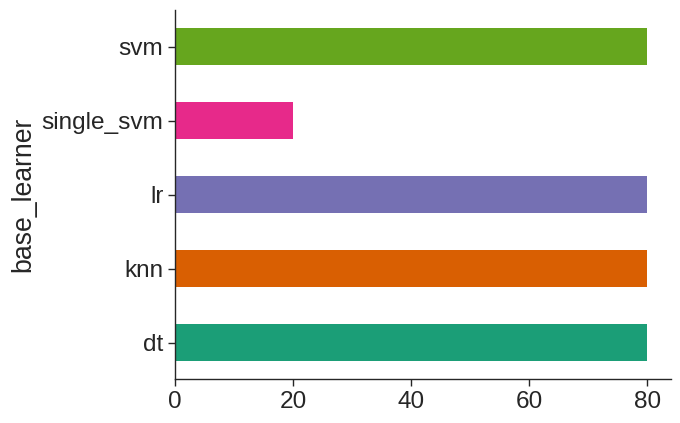

In [ ]:
# @title base_learner

from matplotlib import pyplot as plt
import seaborn as sns
combined_df.groupby('base_learner').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Convert the 'scores' column into a format suitable for boxplot
scores_df = df_results_sorted.query('n_c==6 and phi==0.5').explode('scores')
scores_df['scores'] = scores_df['scores'].astype(float)

single_df = pd.DataFrame({'ensemble_method': ['single_svm'] * len(single_res),
                         'scores': single_res,
                         'base_learner': ['single_svm'] * len(single_res)})

combined_df = pd.concat([scores_df, single_df])

In [ ]:
combined_df.ensemble_method.replace({'densitye': 'DensityE', 'diste': 'DistE',
                                   'single_svm': 'Single Modle', 'maxe': 'MaxE', 'avge': 'AvgE'}, inplace=True)

In [ ]:
combined_df

,base_learner,ensemble_method,n_c,phi,mean_score,std_score,max_score,min_score,scores
647,lr,DensityE,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.970358
647,lr,DensityE,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.972284
647,lr,DensityE,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.974744
647,lr,DensityE,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.973340
647,lr,DensityE,6.0,0.5,0.973269,0.002896,0.97767,0.967414,0.967454
...,...,...,...,...,...,...,...,...,...
15,single_svm,Single Modle,NaN,NaN,NaN,NaN,NaN,NaN,0.914687
16,single_svm,Single Modle,NaN,NaN,NaN,NaN,NaN,NaN,0.936324
17,single_svm,Single Modle,NaN,NaN,NaN,NaN,NaN,NaN,0.909216
18,single_svm,Single Modle,NaN,NaN,NaN,NaN,NaN,NaN,0.953346


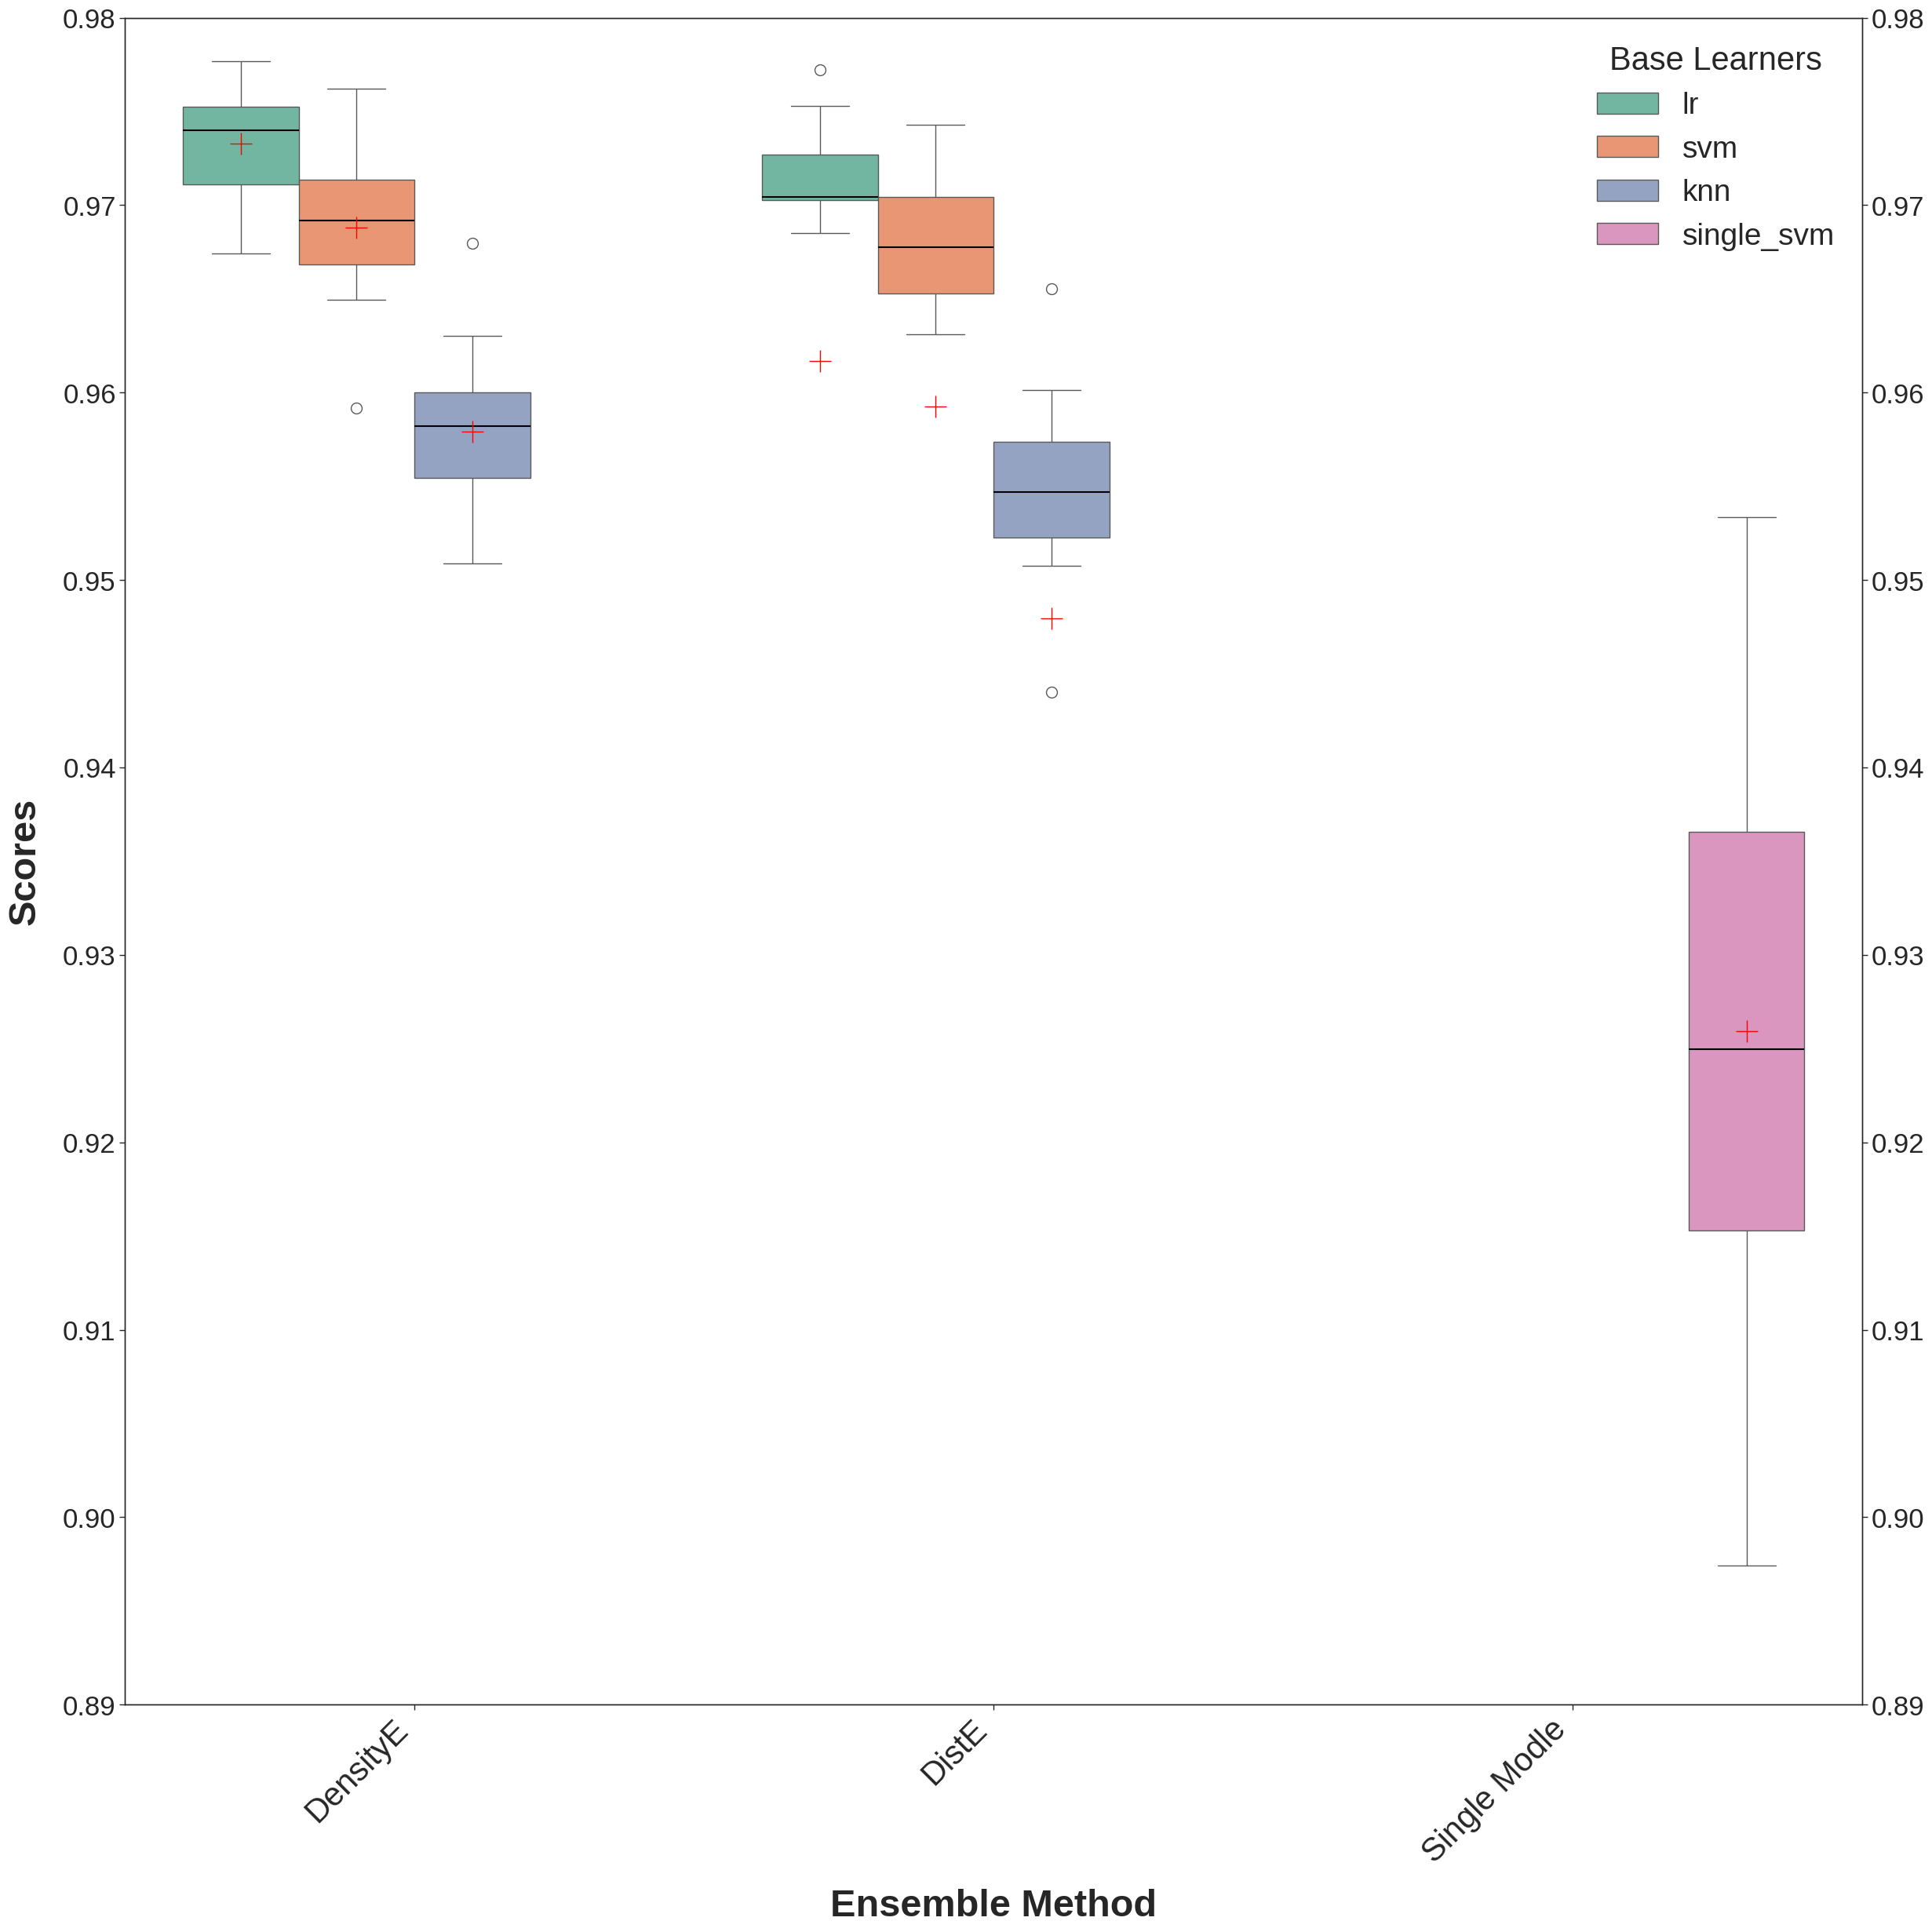

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(25, 25))  # Adjust figure size for a wider plot
sns.boxplot(
    x='ensemble_method',
    y='scores',
    hue='base_learner',
    data=combined_df.query('ensemble_method not in ["AvgE","MaxE"] and base_learner not in ["dt"]'),
    palette='Set2',  # Use a different color palette
    showmeans=True,  # Show mean markers
    meanprops={"marker": "+", "markersize": "20", "markeredgecolor": "red"},  # Customize mean markers
    flierprops={"marker": "o", "markersize": 10, "markerfacecolor": "white"},  # Customize outlier markers
    boxprops={"linewidth": 1},  # Adjust box line width
    whiskerprops={"linewidth": 1},  # Adjust whisker line width
    capprops={"linewidth": 1},  # Adjust cap line width
    medianprops={"linewidth": 1.5, "color": "black"},  # Adjust median line

)

plt.xlabel('Ensemble Method', fontsize=35, fontweight='bold', labelpad=18)
plt.ylabel('Scores', fontsize=35, fontweight='bold', labelpad=18)
plt.xticks(rotation=45, ha='right', fontsize=30)  # Rotate x-axis labels for readability

# Set y-axis limits and ticks like a ruler with 0.01 sections
plt.gca().set_ylim(0.89, 0.98)  # Set y-axis limits from 0 to 1
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.01))  # Major ticks every 0.01 units
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%0.2f'))  # Format ticks to two decimal places

plt.yticks(fontsize=25)
# plt.legend(title='Base Learner', loc='upper right', fontsize=28)
plt.legend(title='Base Learners', loc='upper right', fontsize=28, title_fontsize=30)

# Create a secondary y-axis on the right side with the same scale as the left y-axis
ax_right = plt.gca().twinx()  # Create a twin Axes sharing the x-axis
ax_right.set_ylim(0.89, 0.98)  # Match the y-limits from 0 to 1
ax_right.yaxis.set_major_locator(ticker.MultipleLocator(0.01))  # Same major ticks
ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%0.2f'))  # Same tick format
ax_right.tick_params(axis='y', labelsize=25)  # Set tick label size

plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.savefig('boxplot_comparison.eps', format='eps', dpi=600)
plt.show()


<ipython-input-125-47a12ba71590>:4: UserWarning:

The palette list has more values (10) than needed (4), which may not be intended.



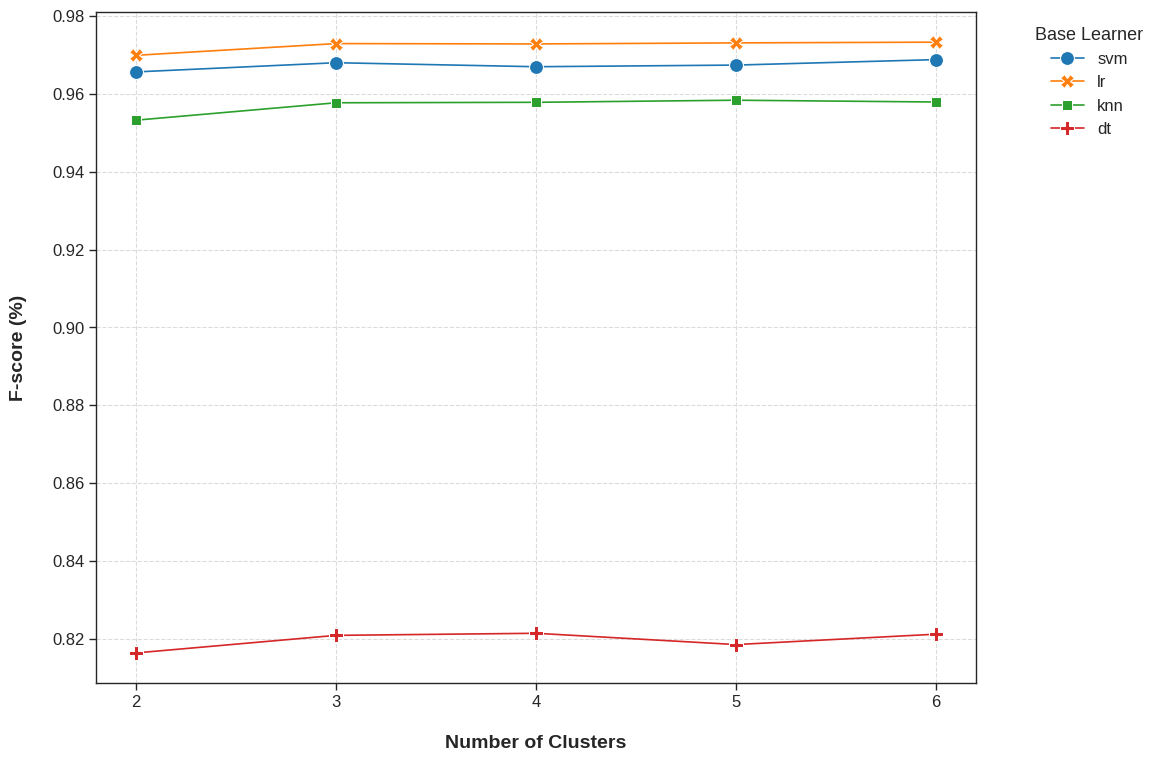

In [ ]:
filtered_res = df_results.query('ensemble_method == "densitye" and base_learner != "sgd"')

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(
    data=filtered_res.query('phi == 0.5'),
    x='n_c', y='mean_score', hue='base_learner', style='base_learner',
    markers=True, markersize=10, dashes=False, palette=colors, ax=ax
)
ax.set_xticks(range(2, 7, 1))
ax.set_xlabel('Number of Clusters', fontsize=14, fontweight='bold', labelpad=18)
ax.set_ylabel('F-score (%)', fontsize=14, fontweight='bold', labelpad=18)
ax.legend(title='Base Learner', title_fontsize='13', fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure as an EPS file with high quality
fig.savefig('fscore_vs_clusters.eps', format='eps', dpi=600)

plt.show()


<ipython-input-122-24fc7f9ea27b>:2: UserWarning:

The palette list has more values (10) than needed (4), which may not be intended.



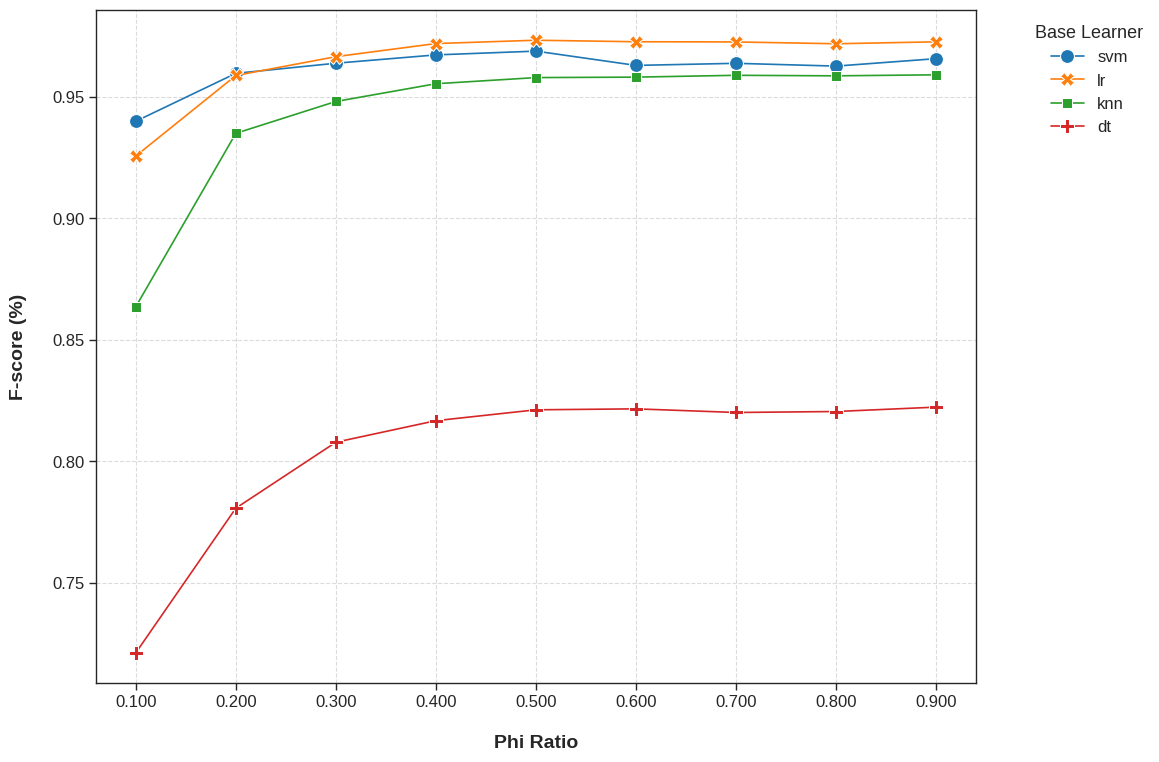

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(
    data=filtered_res.query('n_c == 6'),
    x='phi', y='mean_score', hue='base_learner', style='base_learner',
    markers=True, markersize=10, dashes=False, palette=colors, ax=ax
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.3f}'))
ax.set_xlabel('Phi Ratio', fontsize=14, fontweight='bold', labelpad=18)
ax.set_ylabel('F-score (%)', fontsize=14, fontweight='bold', labelpad=18)
ax.legend(title='Base Learner', title_fontsize='13', fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure as an EPS file with high quality
fig.savefig('fscore_vs_phi.eps', format='eps', dpi=600)

plt.show()


In [ ]:

# Figure 2: F-score vs Number of Clusters
filtered_res = df_results.query('ensemble_method == "densitye" and base_learner != "sgd"')

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(data=filtered_res.query('phi == 0.5'), x='n_c', y='mean_score', hue='base_learner', style='base_learner', markers=True, markersize=10, dashes=False, palette=colors, ax=ax)
ax.set_xticks(range(2, 7, 1))
# ax.set_title('Impact of Cluster Number on F-score', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Clusters', fontsize=14)
ax.set_ylabel('F-score (%)', fontsize=14)
ax.legend(title='Base Learner', title_fontsize='13', fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
save_high_quality_jpeg(fig, 'fscore_vs_clusters.jpg')

# Figure 3: F-score vs Phi Ratio
fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(data=filtered_res.query('n_c == 6'), x='phi', y='mean_score', hue='base_learner', style='base_learner', markers=True, markersize=10, dashes=False, palette=colors, ax=ax)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.3f}'))
# ax.set_title('Effect of Sampling Ratio on F-score', fontsize=16, fontweight='bold')
ax.set_xlabel('Phi Ratio', fontsize=14)
ax.set_ylabel('F-score (%)', fontsize=14)
ax.legend(title='Base Learner', title_fontsize='13', fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
save_high_quality_jpeg(fig, 'fscore_vs_phi.jpg')

<ipython-input-13-b4ea7ab33b3a>:5: UserWarning:

The palette list has more values (10) than needed (4), which may not be intended.

<ipython-input-13-b4ea7ab33b3a>:18: UserWarning:

The palette list has more values (10) than needed (4), which may not be intended.



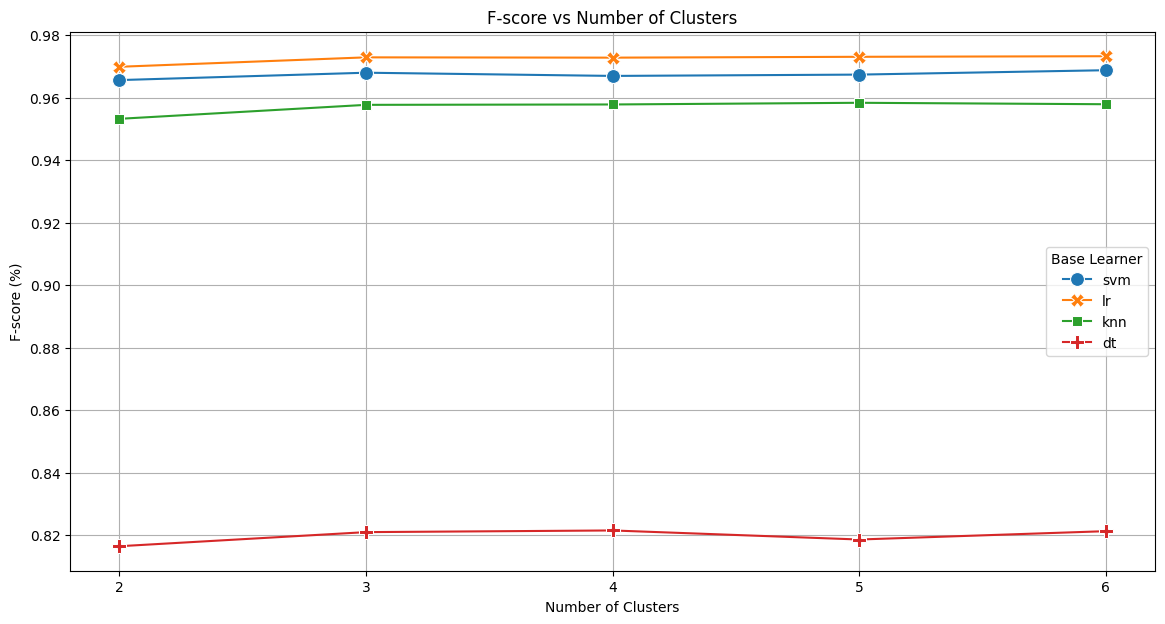

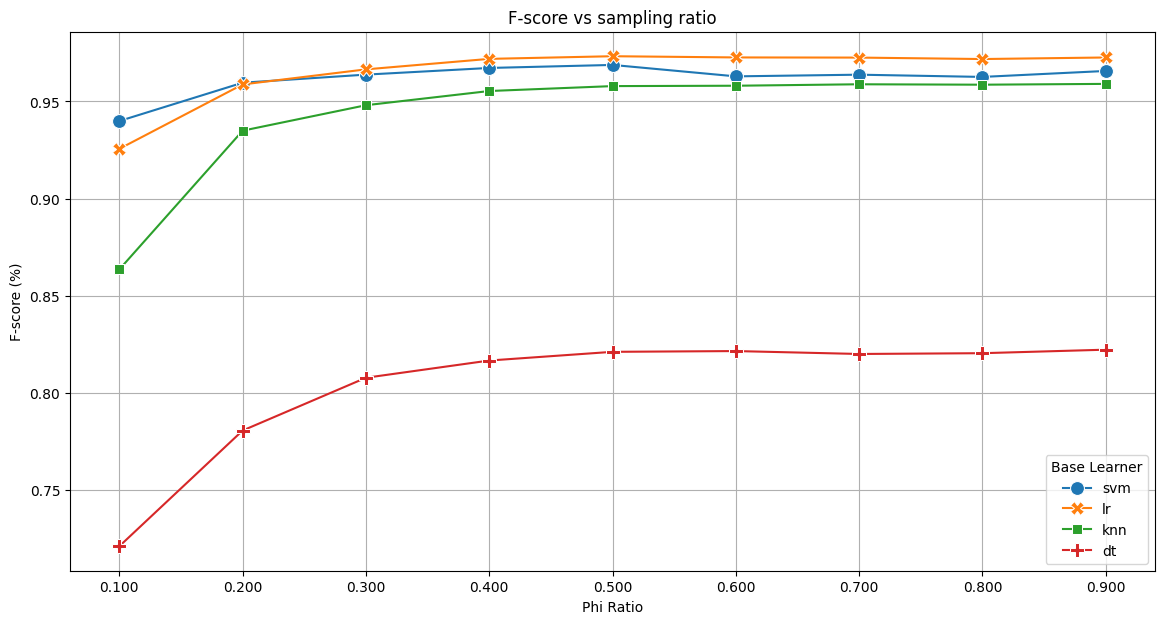

In [ ]:
filtered_res = df_results.query('ensemble_method == "densitye" and base_learner != "sgd"')

# Plotting the results with number of clusters on the x-axis
plt.figure(figsize=(14, 7))
sns.lineplot(data=filtered_res.query('phi == 0.5'), x='n_c', y='mean_score', hue='base_learner', style='base_learner', markers=True, markersize=10, dashes=False, ci=None)

# Customize the x-axis tick labels to divide by 2-6 with a step of 1
plt.xticks(range(2, 7, 1))

plt.title('F-score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('F-score (%)')
plt.legend(title='Base Learner')
plt.grid(True)
plt.show()

# Plotting the results with phi ratio on the x-axis
plt.figure(figsize=(14, 7))
sns.lineplot(data=filtered_res.query('n_c == 6'), x='phi', y='mean_score', hue='base_learner', style='base_learner', markers=True, markersize=10, dashes=False, ci=None)

# Format the x-axis tick labels to 3 decimal places
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.3f}'))

plt.title('F-score vs sampling ratio')
plt.xlabel('Phi Ratio')
plt.ylabel('F-score (%)')
plt.legend(title='Base Learner')
plt.grid(True)
plt.show()

In [ ]:
df_results_sorted.query('n_c == 6' and 'phi == 0.5')

,base_learner,ensemble_method,n_c,phi,mean_score,std_score,max_score,min_score,scores
647,lr,densitye,6,0.5,0.973269,0.002896,0.977670,0.967414,"[0.9703582294526875, 0.97228441650441, 0.97474..."
503,lr,densitye,5,0.5,0.973084,0.002255,0.978155,0.969408,"[0.9694078692167947, 0.9718427175077576, 0.975..."
215,lr,densitye,3,0.5,0.972907,0.002564,0.978183,0.968874,"[0.9703613327982019, 0.9727783464736125, 0.975..."
359,lr,densitye,4,0.5,0.972814,0.002516,0.978168,0.968388,"[0.971829136480411, 0.9732948858848892, 0.9742..."
68,lr,diste,2,0.5,0.971350,0.002215,0.973815,0.965558,"[0.9689250453042836, 0.9733007133461469, 0.972..."
...,...,...,...,...,...,...,...,...,...
222,dt,maxe,3,0.5,0.479541,0.164943,0.733602,0.310251,"[0.3147370356669244, 0.3235023739061976, 0.315..."
366,dt,maxe,4,0.5,0.445641,0.159200,0.671536,0.292304,"[0.30138438582470906, 0.3144878424923476, 0.32..."
78,dt,maxe,2,0.5,0.425118,0.148298,0.661040,0.307256,"[0.3072564630275468, 0.3151565291288489, 0.610..."
654,dt,maxe,6,0.5,0.409953,0.142547,0.652627,0.289082,"[0.6526273003300509, 0.6406918425187186, 0.642..."
